In [ ]:
import sys
from pathlib import Path
for _root in [Path.cwd(), *Path.cwd().parents]:
    if (_root / "paths.py").exists():
        sys.path.insert(0, str(_root))
        break
else:
    raise RuntimeError(
        "Could not find Merge project root (paths.py). Run Jupyter with cwd Merge, notebooks/, or attribution/."
    )
import paths


## Remove Irrelevant

In [1]:
import pandas as pd

# Load the majority vote CSV
majority_df = pd.read_csv(paths.DATA / "MAJORITY_Vote_GPT4o_Self_Reported_Relevancy_Labels.csv")

# Optional: preview the first few rows
print(majority_df.shape)
majority_df.head()


(2000, 55)


,ID,centaur_question,sentence_number,answer,data_source,ID.1,centaur_question.1,sentence_number.1,answer.1,data_source.1,...,label_12,label_13,label_14,label_15,label_16,label_17,label_18,label_19,label_20,label_21
0,ID0001,### Step 1: Read excerpt\n1. A 30-year-old man...,5,I,medxpert,ID0001,### Step 1: Read excerpt\n1. A 30-year-old man...,5,I,medxpert,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,ID0002,### Step 1: Read excerpt\n1. A woman in her 60...,11,D,jama,ID0002,### Step 1: Read excerpt\n1. A woman in her 60...,11,D,jama,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,ID0003,### Step 1: Read excerpt\n1. A 20-year-old wom...,7,G,medxpert,ID0003,### Step 1: Read excerpt\n1. A 20-year-old wom...,7,G,medxpert,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,ID0004,### Step 1: Read excerpt\n1. A 10-year-old gir...,11,A,medbullets,ID0004,### Step 1: Read excerpt\n1. A 10-year-old gir...,11,A,medbullets,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,ID0005,### Step 1: Read excerpt\n1. A 7-year-old boy ...,8,A,medxpert,ID0005,### Step 1: Read excerpt\n1. A 7-year-old boy ...,8,A,medxpert,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [2]:
import pandas as pd

# Load the source CSV files
questions_df = pd.read_csv(paths.DATA / "merged_2k_questions_standardized.csv")
majority_df = pd.read_csv(paths.DATA / "MAJORITY_Vote_GPT4o_Self_Reported_Relevancy_Labels.csv")

# Optional: check shapes and columns to ensure compatibility
print("Questions shape:", questions_df.shape)
print("Relevancy shape:", majority_df.shape)

# Merge by row index (assumes both files are aligned row-wise)
merged_df = pd.concat([questions_df, majority_df], axis=1)

# Save to overwrite the relevancy file
merged_df.to_csv(paths.DATA / "MAJORITY_Vote_GPT4o_Self_Reported_Relevancy_Labels.csv", index=False)

print("Merged and saved successfully.")


Questions shape: (2000, 5)
Relevancy shape: (2000, 55)
Merged and saved successfully.


In [3]:
# Count "Irrelevant" per row
irrelevant_counts = majority_df.apply(lambda row: row.astype(str).str.contains("Irrelevant", case=False).sum(), axis=1)

# Count "ele" per row
ele_counts = majority_df.apply(lambda row: row.astype(str).str.contains("ele", case=False).sum(), axis=1)

# Compute averages and standard deviations
avg_irrelevant = irrelevant_counts.mean()
std_irrelevant = irrelevant_counts.std()

avg_ele = ele_counts.mean()
std_ele = ele_counts.std()

# Display results
print(f"Average irrelevant cells per row: {avg_irrelevant:.2f} (±{std_irrelevant:.2f})")
print(f"Average relevant/irrelevant-labeled cells per row: {avg_ele:.2f} (±{std_ele:.2f})")

# Count "Irrelevant" and "ele" in each row
irrelevant_counts = merged_df.apply(lambda row: row.astype(str).str.contains("Irrelevant", case=False).sum(), axis=1)
ele_counts = merged_df.apply(lambda row: row.astype(str).str.contains("ele", case=False).sum(), axis=1)

# Global statistics
avg_irrelevant = irrelevant_counts.mean()
std_irrelevant = irrelevant_counts.std()
avg_ele = ele_counts.mean()
std_ele = ele_counts.std()

print(f"Global average 'Irrelevant' cells per row: {avg_irrelevant:.2f} (±{std_irrelevant:.2f})")
print(f"Global average 'ele' cells per row: {avg_ele:.2f} (±{std_ele:.2f})")

# Add counts to the DataFrame
merged_df["irrelevant_count"] = irrelevant_counts
merged_df["ele_count"] = ele_counts

# Grouped statistics by data_source
grouped_summary = merged_df.groupby("data_source")[["irrelevant_count", "ele_count"]].agg(["mean", "std"])
grouped_summary.columns = ['_'.join(col) for col in grouped_summary.columns]  # flatten column names

# Display grouped results
print("\nGrouped Statistics by data_source:")
print(grouped_summary.round(2))

Average irrelevant cells per row: 1.52 (±1.59)
Average relevant/irrelevant-labeled cells per row: 11.45 (±4.35)
Global average 'Irrelevant' cells per row: 1.52 (±1.59)
Global average 'ele' cells per row: 12.45 (±4.35)


ValueError: Grouper for 'data_source' not 1-dimensional

In [4]:
# Define label and sentence columns
label_cols = [f"label_{i}" for i in range(1, 22)]
sentence_cols = [f"sentence_{i}" for i in range(1, 22)]

# Make sure both sets of columns exist
assert all(col in majority_df.columns for col in label_cols), "Missing label columns"
assert all(col in majority_df.columns for col in sentence_cols), "Missing sentence columns"

# Function to filter out irrelevant sentences
def remove_irrelevant_sentences(row):
    filtered_sentences = [
        row[s_col].strip() for s_col, l_col in zip(sentence_cols, label_cols)
        if pd.notna(row[l_col]) and row[l_col] != "Irrelevant" and pd.notna(row[s_col])
    ]
    return "\n".join(f"{i+1}. {s}" for i, s in enumerate(filtered_sentences))

# Apply row-wise to create new column
majority_df["Remove_Irrelevant"] = majority_df.apply(remove_irrelevant_sentences, axis=1)
print(majority_df["Remove_Irrelevant"])


0       1. 1. A 30-year-old man is brought to the emer...
1       1. 1. A woman in her 60s with a history of hyp...
2       1. 1. A 20-year-old woman comes to the primary...
3       1. 1. A 10-year-old girl is admitted to the me...
4       1. 1. A 7-year-old boy is brought to the emerg...
                              ...                        
1995    1. 1. A 68-year-old female presents to the eme...
1996    1. 1. A 27-year-old woman presents with a 4-mo...
1997    1. 1. A 6-month-old girl is brought to the ped...
1998    1. 1. A 28-year-old woman visits her physician...
1999    1. 1. A 30-year-old nulliparous female present...
Name: Remove_Irrelevant, Length: 2000, dtype: object


In [5]:
import re

# Function to clean sentence numbering inside sentence body
def clean_and_filter_sentences(row):
    kept_sentences = []
    for i, (s_col, l_col) in enumerate(zip(sentence_cols, label_cols)):
        label = row[l_col]
        sentence = row[s_col]
        if pd.notna(label) and label != "Irrelevant" and pd.notna(sentence):
            # Remove internal numbering like '7.' or '3.' at the start of sentence body
            cleaned = re.sub(r'^\d+\.\s*', '', sentence.strip())
            kept_sentences.append(cleaned)
    return kept_sentences

# Apply to get list of cleaned sentences
majority_df["Remove_Irrelevant_List"] = majority_df.apply(clean_and_filter_sentences, axis=1)

# Join into final string for prompt use, with new external numbering
majority_df["Remove_Irrelevant"] = majority_df["Remove_Irrelevant_List"].apply(
    lambda sents: "\n".join(f"{i+1}. {s}" for i, s in enumerate(sents))
)

# Count remaining sentences
majority_df["Remove_Irrelevant_Sentence_Num"] = majority_df["Remove_Irrelevant_List"].apply(len)

# Drop intermediate list column if not needed
majority_df.drop(columns=["Remove_Irrelevant_List"], inplace=True)
majority_df.to_csv(paths.DATA / "test_Removal.csv", index=False)

In [ ]:
import pandas as pd
import re
import time

# Load the existing CSV
majority_df = pd.read_csv(paths.DATA / "MAJORITY_Vote_GPT4o_Self_Reported_Relevancy_Labels.csv")

# Output file path
output_path = "THIRD_GPT4o_Remove_Irrelevant.csv"
output_columns = ["row_index", "GPT4o_answer"]

# Initialize CSV with header
pd.DataFrame(columns=output_columns).to_csv(output_path, index=False)

# Process each row
for i in range(min(len(majority_df), 2001)):
    try:
        current_answer = str(majority_df.loc[i, "GPT4o_answer"]).strip().upper()
        
        # Skip if already filled
        if current_answer and current_answer not in ["NAN", ""]:
            gpt_answer = current_answer
        else:
            formatted_sentences = majority_df.loc[i, "Remove_Irrelevant"]
            options = majority_df.loc[i, "question_options"]

            prompt = f"""
You are given a list of sentences from a clinical vignette and a multiple-choice clinical question.

Your task is to select the most appropriate answer from the given options.

Question and Options:
{options.strip()}

Sentences:
{formatted_sentences}

Please respond with your answer only in the format: "Answer: X"
""".strip()

            # Submit to GPT-4o
            response = client.chat.completions.create(
                model="gpt-4o",
                messages=[{"role": "user", "content": prompt}],
                temperature=0
            )

            content = response.choices[0].message.content.strip()

            # Extract answer
            answer_match = re.search(r"Answer:\s*([A-E])", content, re.IGNORECASE)
            gpt_answer = answer_match.group(1).upper() if answer_match else None

    except Exception as e:
        print(f"Error at row {i}: {e}")
        gpt_answer = None

    # Write result
    result_row = pd.DataFrame([[i, gpt_answer]], columns=output_columns)
    result_row.to_csv(output_path, mode="a", index=False, header=False)
    print(f"Row {i} processed.")
    
    time.sleep(0.2)


Error at row 0: 'GPT4o_answer'
Row 0 processed.
Error at row 1: 'GPT4o_answer'
Row 1 processed.
Error at row 2: 'GPT4o_answer'
Row 2 processed.
Error at row 3: 'GPT4o_answer'
Row 3 processed.
Error at row 4: 'GPT4o_answer'
Row 4 processed.
Error at row 5: 'GPT4o_answer'
Row 5 processed.
Error at row 6: 'GPT4o_answer'
Row 6 processed.
Error at row 7: 'GPT4o_answer'
Row 7 processed.
Error at row 8: 'GPT4o_answer'
Row 8 processed.
Error at row 9: 'GPT4o_answer'
Row 9 processed.
Error at row 10: 'GPT4o_answer'
Row 10 processed.
Error at row 11: 'GPT4o_answer'
Row 11 processed.
Error at row 12: 'GPT4o_answer'
Row 12 processed.
Error at row 13: 'GPT4o_answer'
Row 13 processed.
Error at row 14: 'GPT4o_answer'
Row 14 processed.
Error at row 15: 'GPT4o_answer'
Row 15 processed.
Error at row 16: 'GPT4o_answer'
Row 16 processed.
Error at row 17: 'GPT4o_answer'
Row 17 processed.
Error at row 18: 'GPT4o_answer'
Row 18 processed.
Error at row 19: 'GPT4o_answer'
Row 19 processed.
Error at row 20: 'GP

In [ ]:
# Prepare output file path and headers
output_path = "THIRD_GPT4o_Remove_Irrelevant.csv"
output_columns = ["row_index", "GPT4o_answer"] + [f"label_{j+1}" for j in range(21)]

# Create header row
pd.DataFrame(columns=output_columns).to_csv(output_path, index=False)

# Process each row
for i in range(min(len(majority_df), 2001)):
    try:
        formatted_sentences = majority_df.loc[i, "Remove_Irrelevant"]
        options = majority_df.loc[i, "question_options"]

        prompt = f"""
You are given a list of sentences from a clinical vignette and a multiple-choice clinical question.

Your task is twofold:
(1) Select the most appropriate answer from the given options.
(2) Label each sentence as either [High Relevance], [Low Relevance], or [Irrelevant], based on its contribution to answering the question.

Definitions:
[High Relevance]: Sentences that directly support the correct answer with essential clinical information (e.g., diagnosis, key test results).
[Low Relevance]: Sentences that provide useful context or background but are not critical to answering.
[Irrelevant]: Sentences unrelated to the question or not useful for reasoning.

Question and Options:
{options.strip()}

Sentences:
{formatted_sentences}

Please provide your answer selection first (e.g., "Answer: B"), followed by the relevance label for each sentence in order.
""".strip()

        # Submit to GPT-4o
        response = client.chat.completions.create(
            model="gpt-4o",
            messages=[{"role": "user", "content": prompt}],
            temperature=0
        )

        content = response.choices[0].message.content.strip()

        # Extract GPT answer
        answer_match = re.search(r"Answer:\s*([A-E])", content, re.IGNORECASE)
        gpt_answer = answer_match.group(1).upper() if answer_match else None

        # Extract sentence labels
        labels = re.findall(r"\[\s*(High Relevance|Low Relevance|Irrelevant)\s*\]", content, re.IGNORECASE)
        labels = [label.title() for label in labels]
        labels = labels[:21] + [None] * (21 - len(labels))

    except Exception as e:
        print(f"Error at row {i}: {e}")
        gpt_answer = None
        labels = [None] * 21

    # Create output row
    result_row = pd.DataFrame(
        [[i, gpt_answer] + labels],
        columns=output_columns
    )

    # Append to CSV
    result_row.to_csv(output_path, mode="a", index=False, header=False)
    print(f"Row {i} processed and saved.")

    time.sleep(0.2)  # optional rate limiting


Row 287 processed and saved.
Row 288 processed and saved.
Row 289 processed and saved.
Row 290 processed and saved.
Row 291 processed and saved.
Row 292 processed and saved.
Row 293 processed and saved.
Row 294 processed and saved.
Row 295 processed and saved.
Row 296 processed and saved.
Row 297 processed and saved.
Row 298 processed and saved.
Row 299 processed and saved.
Row 300 processed and saved.
Row 301 processed and saved.
Row 302 processed and saved.
Row 303 processed and saved.
Row 304 processed and saved.
Row 305 processed and saved.
Row 306 processed and saved.
Row 307 processed and saved.
Row 308 processed and saved.
Row 309 processed and saved.
Row 310 processed and saved.
Row 311 processed and saved.
Row 312 processed and saved.
Row 313 processed and saved.
Row 314 processed and saved.
Row 315 processed and saved.
Row 316 processed and saved.
Row 317 processed and saved.
Row 318 processed and saved.
Row 319 processed and saved.
Row 320 processed and saved.
Row 321 proces

Row 570 processed and saved.
Row 571 processed and saved.
Row 572 processed and saved.
Row 573 processed and saved.
Row 574 processed and saved.
Row 575 processed and saved.
Row 576 processed and saved.
Row 577 processed and saved.
Row 578 processed and saved.
Row 579 processed and saved.
Row 580 processed and saved.
Row 581 processed and saved.
Row 582 processed and saved.
Row 583 processed and saved.
Row 584 processed and saved.
Row 585 processed and saved.
Row 586 processed and saved.
Row 587 processed and saved.
Row 588 processed and saved.
Row 589 processed and saved.
Row 590 processed and saved.
Row 591 processed and saved.
Row 592 processed and saved.
Row 593 processed and saved.
Row 594 processed and saved.
Row 595 processed and saved.
Row 596 processed and saved.
Row 597 processed and saved.
Row 598 processed and saved.
Row 599 processed and saved.
Row 600 processed and saved.
Row 601 processed and saved.
Row 602 processed and saved.
Row 603 processed and saved.
Row 604 proces

Row 853 processed and saved.
Row 854 processed and saved.
Row 855 processed and saved.
Row 856 processed and saved.
Row 857 processed and saved.
Row 858 processed and saved.
Row 859 processed and saved.
Row 860 processed and saved.
Row 861 processed and saved.
Row 862 processed and saved.
Row 863 processed and saved.
Row 864 processed and saved.
Row 865 processed and saved.
Row 866 processed and saved.
Row 867 processed and saved.
Row 868 processed and saved.
Row 869 processed and saved.
Row 870 processed and saved.
Row 871 processed and saved.
Row 872 processed and saved.
Row 873 processed and saved.
Row 874 processed and saved.
Row 875 processed and saved.
Row 876 processed and saved.
Row 877 processed and saved.
Row 878 processed and saved.
Row 879 processed and saved.
Row 880 processed and saved.
Row 881 processed and saved.
Row 882 processed and saved.
Row 883 processed and saved.
Row 884 processed and saved.
Row 885 processed and saved.
Row 886 processed and saved.
Row 887 proces

Row 1156 processed and saved.
Row 1157 processed and saved.
Row 1158 processed and saved.
Row 1159 processed and saved.
Row 1160 processed and saved.
Row 1161 processed and saved.
Row 1162 processed and saved.
Row 1163 processed and saved.
Row 1164 processed and saved.
Row 1165 processed and saved.
Row 1166 processed and saved.
Row 1167 processed and saved.
Row 1168 processed and saved.
Row 1169 processed and saved.
Row 1170 processed and saved.
Row 1171 processed and saved.
Row 1172 processed and saved.
Row 1173 processed and saved.
Row 1174 processed and saved.
Row 1175 processed and saved.
Row 1176 processed and saved.
Row 1177 processed and saved.
Row 1178 processed and saved.
Row 1179 processed and saved.
Row 1180 processed and saved.
Row 1181 processed and saved.
Row 1182 processed and saved.
Row 1183 processed and saved.
Row 1184 processed and saved.
Row 1185 processed and saved.
Row 1186 processed and saved.
Row 1187 processed and saved.
Row 1188 processed and saved.
Row 1189 p

Row 1430 processed and saved.
Row 1431 processed and saved.
Row 1432 processed and saved.
Row 1433 processed and saved.
Row 1434 processed and saved.
Row 1435 processed and saved.
Row 1436 processed and saved.
Row 1437 processed and saved.
Row 1438 processed and saved.
Row 1439 processed and saved.
Row 1440 processed and saved.
Row 1441 processed and saved.
Row 1442 processed and saved.
Row 1443 processed and saved.
Row 1444 processed and saved.
Row 1445 processed and saved.
Row 1446 processed and saved.
Row 1447 processed and saved.
Row 1448 processed and saved.
Row 1449 processed and saved.
Row 1450 processed and saved.
Row 1451 processed and saved.
Row 1452 processed and saved.
Row 1453 processed and saved.
Row 1454 processed and saved.
Row 1455 processed and saved.
Row 1456 processed and saved.
Row 1457 processed and saved.
Row 1458 processed and saved.
Row 1459 processed and saved.
Row 1460 processed and saved.
Row 1461 processed and saved.
Row 1462 processed and saved.
Row 1463 p

Row 1704 processed and saved.
Row 1705 processed and saved.
Row 1706 processed and saved.
Row 1707 processed and saved.
Row 1708 processed and saved.
Row 1709 processed and saved.
Row 1710 processed and saved.
Row 1711 processed and saved.
Row 1712 processed and saved.
Row 1713 processed and saved.
Row 1714 processed and saved.
Row 1715 processed and saved.
Row 1716 processed and saved.
Row 1717 processed and saved.
Row 1718 processed and saved.
Row 1719 processed and saved.
Row 1720 processed and saved.
Row 1721 processed and saved.
Row 1722 processed and saved.
Row 1723 processed and saved.
Row 1724 processed and saved.
Row 1725 processed and saved.
Row 1726 processed and saved.
Row 1727 processed and saved.
Row 1728 processed and saved.
Row 1729 processed and saved.
Row 1730 processed and saved.
Row 1731 processed and saved.
Row 1732 processed and saved.
Row 1733 processed and saved.
Row 1734 processed and saved.
Row 1735 processed and saved.
Row 1736 processed and saved.
Row 1737 p

Row 1978 processed and saved.
Row 1979 processed and saved.
Row 1980 processed and saved.
Row 1981 processed and saved.
Row 1982 processed and saved.
Row 1983 processed and saved.
Row 1984 processed and saved.
Row 1985 processed and saved.
Row 1986 processed and saved.
Row 1987 processed and saved.
Row 1988 processed and saved.
Row 1989 processed and saved.
Row 1990 processed and saved.
Row 1991 processed and saved.
Row 1992 processed and saved.
Row 1993 processed and saved.
Row 1994 processed and saved.
Row 1995 processed and saved.
Row 1996 processed and saved.
Row 1997 processed and saved.
Row 1998 processed and saved.
Row 1999 processed and saved.


In [6]:
import pandas as pd
import matplotlib.pyplot as plt

# Define the label columns
label_cols = [f"label_{i}" for i in range(1, 22)]

# Safe CSV reading
def safe_read_csv(filepath):
    try:
        return pd.read_csv(filepath, on_bad_lines="skip")
    except Exception as e:
        print(f"Error reading {filepath}: {e}")
        return None

# Load the files
df1 = safe_read_csv(paths.DATA / "FIRST_GPT4o_Remove_Irrelevant.csv")
df2 = safe_read_csv(paths.DATA / "SECOND_GPT4o_Remove_Irrelevant.csv")
df3 = safe_read_csv("THIRD_GPT4o_Remove_Irrelevant.csv")

# Get value counts for each label column
def get_label_distribution(df):
    if df is not None:
        return df[label_cols].apply(pd.Series.value_counts).fillna(0).astype(int)
    else:
        return pd.DataFrame()

# Summarize each dataset
summary1 = get_label_distribution(df1)
summary2 = get_label_distribution(df2)
summary3 = get_label_distribution(df3)

# Add dataset names as new index level
summary1.index.name = "Label Value"
summary2.index.name = "Label Value"
summary3.index.name = "Label Value"

summary1["Dataset"] = "FIRST"
summary2["Dataset"] = "SECOND"
summary3["Dataset"] = "THIRD"

# Stack and reshape
summary_all = pd.concat([summary1, summary2, summary3])
summary_all = summary_all.reset_index()

# Display summary
print("Label Value Counts Across All Datasets and Columns:")
print(summary_all)

Label Value Counts Across All Datasets and Columns:
      Label Value  label_1  label_2  label_3  label_4  label_5  label_6  \
0  High Relevance      931      717      742      730      649      628   
1      Irrelevant       51      128      173      189      158      147   
2   Low Relevance      919     1040      927      733      622      442   
3  High Relevance      937      711      740      731      652      640   
4      Irrelevant       52      134      174      196      174      151   
5   Low Relevance      914     1042      930      727      604      424   
6  High Relevance      922      717      752      727      650      632   
7      Irrelevant       50      130      166      192      174      150   
8   Low Relevance      930     1039      925      734      605      436   

   label_7  label_8  label_9  ...  label_13  label_14  label_15  label_16  \
0      532      432      330  ...        90        66        39        30   
1      126       98       76  ...        31

In [21]:
import pandas as pd
import numpy as np

# Load truth and predictions
df_truth = pd.read_csv(paths.DATA / "merged_2k_questions_standardized.csv")
df1 = safe_read_csv(paths.DATA / "FIRST_GPT4o_Remove_Irrelevant.csv")
df2 = safe_read_csv(paths.DATA / "SECOND_GPT4o_Remove_Irrelevant.csv")
df3 = safe_read_csv("THIRD_GPT4o_Remove_Irrelevant.csv")

# Add source labels
df1["source"] = "FIRST"
df2["source"] = "SECOND"
df3["source"] = "THIRD"

# Concatenate
df_pred = pd.concat([df1, df2, df3], ignore_index=True)

# Merge with truth
if "QA_ID" in df_pred.columns and "QA_ID" in df_truth.columns:
    merged_df = pd.merge(df_pred, df_truth[["QA_ID", "answer"]], on="QA_ID", how="inner")
else:
    df_truth = df_truth.reset_index(drop=True)
    df_pred = df_pred.reset_index(drop=True)
    merged_df = df_pred.copy()
    merged_df["answer"] = df_truth["answer"]

# Normalize
merged_df["GPT4o_answer"] = merged_df["GPT4o_answer"].astype(str).str.strip().str.upper()
merged_df["answer"] = merged_df["answer"].astype(str).str.strip().str.upper()

# Identify empty predictions
merged_df["is_empty"] = merged_df["GPT4o_answer"] == ""

# Compute correctness
merged_df["correct"] = merged_df["GPT4o_answer"] == merged_df["answer"]

# Grouped metrics
grouped = merged_df.groupby("source")
for source, group in grouped:
    total = len(group)
    correct = group["correct"].sum()
    empty = group["is_empty"].sum()
    accuracy = correct / total
    std = group["correct"].std(ddof=0)
    print(f"{source} — Accuracy: {accuracy:.2%} ({correct}/{total}), Std Dev: {std:.4f}, Empty: {empty} rows")


FIRST — Accuracy: 41.35% (827/2000), Std Dev: 0.4925, Empty: 0 rows
SECOND — Accuracy: 26.25% (525/2000), Std Dev: 0.4400, Empty: 0 rows
THIRD — Accuracy: 26.55% (531/2000), Std Dev: 0.4416, Empty: 0 rows


In [22]:
import pandas as pd
from collections import Counter

# Define label columns
label_cols = [f"label_{i}" for i in range(1, 22)]

# Define full set of columns to include in output
full_cols = [
    "GPT4o_answer", 
    "label_1", "label_2", "label_3", "label_4", "label_5",
"label_6", "label_7", "label_8", "label_9", "label_10",
"label_11", "label_12", "label_13", "label_14", "label_15",
"label_16", "label_17", "label_18", "label_19", "label_20", "label_21"
]

# Step 1: Compute majority votes for each label column
majority_labels = []
for idx in range(len(df1)):
    row_votes = {}
    for col in label_cols:
        votes = [
            df1.at[idx, col],
            df2.at[idx, col],
            df3.at[idx, col]
        ]
        vote_counts = Counter(votes)
        majority = vote_counts.most_common(1)[0][0]
        row_votes[col] = majority
    majority_labels.append(row_votes)

# Step 2: Construct majority label DataFrame
majority_df = pd.DataFrame(majority_labels)

# Step 3: Concatenate with full metadata from df1 (assuming df1 has all the columns)
if all(col in df1.columns for col in full_cols):
    merged_df = pd.concat([df1[full_cols], majority_df], axis=1)
else:
    missing = [col for col in full_cols if col not in df1.columns]
    raise ValueError(f"The following expected columns are missing in df1: {missing}")

# Step 4: Save to CSV
merged_df.to_csv(paths.DATA / "REMOVE_IRR_MAJORITY_Vote_GPT4o_Self_Reported_Relevancy_Labels.csv", index=False)


In [23]:
import pandas as pd

# Load the source CSV files
questions_df = pd.read_csv(paths.DATA / "merged_2k_questions_standardized.csv")
relevancy_df = pd.read_csv(paths.DATA / "REMOVE_IRR_MAJORITY_Vote_GPT4o_Self_Reported_Relevancy_Labels.csv")

# Optional: check shapes and columns to ensure compatibility
print("Questions shape:", questions_df.shape)
print("Relevancy shape:", relevancy_df.shape)

# Merge by row index (assumes both files are aligned row-wise)
merged_df = pd.concat([questions_df, relevancy_df], axis=1)

# Save to overwrite the relevancy file
merged_df.to_csv(paths.DATA / "REMOVE_IRR_MAJORITY_Vote_GPT4o_Self_Reported_Relevancy_Labels.csv", index=False)

print("Merged and saved successfully.")


Questions shape: (2000, 5)
Relevancy shape: (2000, 43)
Merged and saved successfully.


In [25]:
import pandas as pd

# Load both CSVs
questions_df = pd.read_csv(paths.DATA / "merged_2k_questions_standardized.csv")
relevancy_df = pd.read_csv(paths.DATA / "REMOVE_IRR_MAJORITY_Vote_GPT4o_Self_Reported_Relevancy_Labels.csv")

# Drop data_source from one of the two if both contain it
if "data_source" in relevancy_df.columns and "data_source" in questions_df.columns:
    relevancy_df = relevancy_df.drop(columns=["data_source"])  # or rename if needed

# Merge the two DataFrames row-wise
merged_df = pd.concat([questions_df, relevancy_df], axis=1)
# Drop all columns with ".1" in the name
merged_df = merged_df.loc[:, ~merged_df.columns.str.contains(r"\.1$", regex=True)]

# Count "Irrelevant" and "ele" per row
irrelevant_counts = merged_df.apply(lambda row: row.astype(str).str.contains("Irrelevant", case=False).sum(), axis=1)
ele_counts = merged_df.apply(lambda row: row.astype(str).str.contains("ele", case=False).sum(), axis=1)

# Add counts to the merged DataFrame
merged_df["irrelevant_count"] = irrelevant_counts
merged_df["ele_count"] = ele_counts

# Compute global stats
print(f"Global average 'Irrelevant' cells per row: {irrelevant_counts.mean():.2f} (±{irrelevant_counts.std():.2f})")
print(f"Global average 'ele' cells per row: {ele_counts.mean():.2f} (±{ele_counts.std():.2f})")

# Confirm that 'data_source' is now unique and 1D
print("\nColumn names in merged_df:")
print(merged_df.columns.tolist())

# Group by data_source
grouped_summary = merged_df.groupby("data_source")[["irrelevant_count", "ele_count"]].agg(["mean", "std"])
grouped_summary.columns = ['_'.join(col) for col in grouped_summary.columns]

print("\nGrouped Statistics by data_source:")
print(grouped_summary.round(2))


Global average 'Irrelevant' cells per row: 0.71 (±1.16)
Global average 'ele' cells per row: 8.95 (±3.86)

Column names in merged_df:
['ID', 'centaur_question', 'sentence_number', 'answer', 'data_source', 'ID', 'centaur_question', 'sentence_number', 'answer', 'GPT4o_answer', 'label_1', 'label_2', 'label_3', 'label_4', 'label_5', 'label_6', 'label_7', 'label_8', 'label_9', 'label_10', 'label_11', 'label_12', 'label_13', 'label_14', 'label_15', 'label_16', 'label_17', 'label_18', 'label_19', 'label_20', 'label_21', 'irrelevant_count', 'ele_count']

Grouped Statistics by data_source:
             irrelevant_count_mean  irrelevant_count_std  ele_count_mean  \
data_source                                                                
jama                          0.88                  1.33           10.83   
medbullets                    0.94                  1.05            9.16   
medxpert                      0.53                  1.05            7.44   
mmlu                          0.4

In [8]:
count_df = pd.DataFrame({
    "FIRST": df1[label_cols].stack().map({
        "High Relevance": "High Relevance",
        "Low Relevance": "Low Relevance",
        "Irrelevant": "Irrelevant"
    }).value_counts(),
    "SECOND": df2[label_cols].stack().map({
        "High Relevance": "High Relevance",
        "Low Relevance": "Low Relevance",
        "Irrelevant": "Irrelevant"
    }).value_counts(),
    "THIRD": df3[label_cols].stack().map({
        "High Relevance": "High Relevance",
        "Low Relevance": "Low Relevance",
        "Irrelevant": "Irrelevant"
    }).value_counts()
}).fillna(0).astype(int).loc[["High Relevance", "Low Relevance", "Irrelevant"]]


def generate_significance_table(count_df):
    label_order = ["High Relevance", "Low Relevance", "Irrelevant"]
    raters = ["FIRST", "SECOND", "THIRD"]
    results = []

    for label in label_order:
        for r1, r2 in combinations(raters, 2):
            count1 = count_df.loc[label, r1]
            count2 = count_df.loc[label, r2]
            total1 = count_df[r1].sum()
            total2 = count_df[r2].sum()

            stat, pval = proportions_ztest([count1, count2], [total1, total2])
            prop1 = count1 / total1
            prop2 = count2 / total2

            if pval < 0.001:
                significance = "***"
            elif pval < 0.01:
                significance = "**"
            elif pval < 0.05:
                significance = "*"
            else:
                significance = "ns"

            results.append({
                "Relevance Category": label,
                "Rater 1": r1,
                "Rater 2": r2,
                "Count R1": count1,
                "Count R2": count2,
                "Total R1": total1,
                "Total R2": total2,
                "Proportion R1": round(prop1, 3),
                "Proportion R2": round(prop2, 3),
                "p-value": round(pval, 50),
                "Significance": significance
            })

    return pd.DataFrame(results)

significance_table = generate_significance_table(count_df)
display(significance_table)


NameError: name 'combinations' is not defined

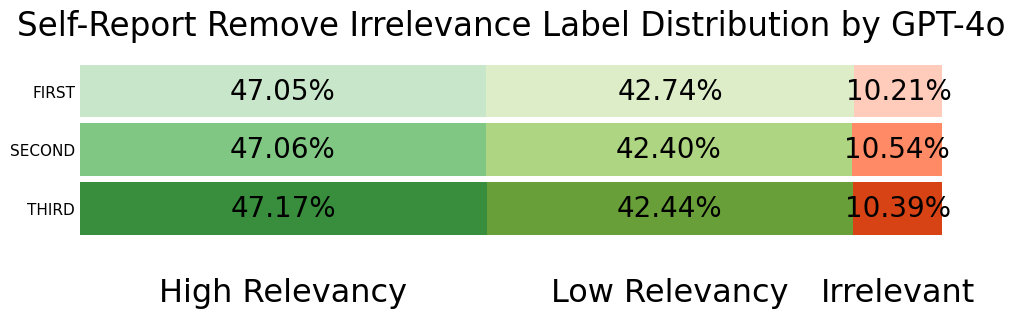

In [15]:
import pandas as pd
import matplotlib.pyplot as plt

# Define label order
label_order = ["High Relevance", "Low Relevance", "Irrelevant"]

# Define safe_stack
def safe_stack(df):
    return df[label_cols].stack().map({
        "High Relevance": "High Relevance",
        "Low Relevance": "Low Relevance",
        "Irrelevant": "Irrelevant"
    }).value_counts()

# Generate count dataframe
count_df = pd.DataFrame({
    "FIRST": safe_stack(df1),
    "SECOND": safe_stack(df2),
    "THIRD": safe_stack(df3),
}).fillna(0).astype(int).loc[label_order]

import pandas as pd
import matplotlib.pyplot as plt

def plot_stacked_with_top_labels(count_df, title="Self-Report Remove Irrelevance Label Distribution by GPT-4o"):
    # Define keys and full labels
    label_keys = ["High Relevance", "Low Relevance", "Irrelevant"]
    label_titles = ["High Relevancy", "Low Relevancy", "Irrelevant"]
    prop_df = count_df.divide(count_df.sum(axis=0), axis=1)
    annotators = count_df.columns.tolist()

    # Color gradient for each label: light (FIRST) to dark (THIRD)
    color_palette = {
        "High Relevance": ["#C8E6C9", "#81C784", "#388E3C"],    
        "Low Relevance":  ["#DCEDC8", "#AED581", "#689F38"],    
        "Irrelevant":     ["#FFCCBC", "#FF8A65", "#D84315"]     
    }

    fig, ax = plt.subplots(figsize=(10, 3.6))
    y_pos = range(len(annotators))
    left = [0] * len(annotators)

    # Track for top label placement
    top_label_positions = []

    # Plot horizontal bars
    for label_idx, label in enumerate(label_keys):
        values = prop_df.loc[label]
        for i, annotator in enumerate(annotators):
            val = values[annotator]
            color = color_palette[label][i]
            ax.barh(i, val, left=left[i], height=0.9, color=color)

            # Add percentage text inside each bar if it's wide enough
            if val > 0.01:
                ax.text(left[i] + val / 2, i, f"{val * 100:.2f}%",
                        ha='center', va='center', fontsize=20, color='black')


            # Save midpoint for top label
            if i == 0:
                top_label_positions.append(left[i] + val / 2)

            left[i] += val

    # Add category labels at top (above FIRST row)
    for i, label_text in enumerate(label_titles):
        ax.text(top_label_positions[i], 3.7, label_text,
                ha='center', va='bottom', fontsize=23)

    # Formatting
    ax.set_yticks(y_pos)
    ax.set_yticklabels(annotators, fontsize=11)
    ax.set_xticks([])
    ax.set_xlim(0, 1)
    ax.invert_yaxis()
    ax.set_title(title, fontsize=23.5, pad=15)
    ax.tick_params(axis='y', length=0)
    for spine in ax.spines.values():
        spine.set_visible(False)

    plt.tight_layout()
    plt.savefig(paths.FIGURES / "GPT4o_remove_irrelevance_distribution.pdf", format="pdf", bbox_inches="tight")
    plt.show()

plot_stacked_with_top_labels(count_df)

In [13]:
# Check for shape and preview
print("DF1 shape:", df1.shape)
print("DF2 shape:", df2.shape)
print("DF3 shape:", df3.shape)

# Check label distributions in each
print("DF1 label distribution:")
print(safe_stack(df1).sort_index())

print("\nDF2 label distribution:")
print(safe_stack(df2).sort_index())

print("\nDF3 label distribution:")
print(safe_stack(df3).sort_index())


DF1 shape: (2000, 24)
DF2 shape: (2000, 24)
DF3 shape: (2000, 24)
DF1 label distribution:
High Relevance    6536
Irrelevant        1418
Low Relevance     5937
Name: count, dtype: int64

DF2 label distribution:
High Relevance    6531
Irrelevant        1463
Low Relevance     5885
Name: count, dtype: int64

DF3 label distribution:
High Relevance    6561
Irrelevant        1445
Low Relevance     5902
Name: count, dtype: int64


In [29]:
import pandas as pd
from collections import Counter

# Define label columns
label_cols = [f"label_{i}" for i in range(1, 22)]

# Create full column list
full_cols = [
    "row_index", "GPT4o_answer", "label_1", "label_2", "label_3", "label_4", "label_5",
    "label_6", "label_7", "label_8", "label_9", "label_10", "label_11", "label_12",
    "label_13", "label_14", "label_15", "label_16", "label_17", "label_18", "label_19",
    "label_20", "label_21"
]

# Step 1: Compute majority votes for each label column
majority_labels = []
for idx in range(len(df1)):
    row_votes = {}
    for col in label_cols:
        votes = [
            df1.at[idx, col],
            df2.at[idx, col],
            df3.at[idx, col]
        ]
        vote_counts = Counter(votes)
        majority = vote_counts.most_common(1)[0][0]
        row_votes[col] = majority
    majority_labels.append(row_votes)

# Step 2: Construct majority label DataFrame
majority_df = pd.DataFrame(majority_labels)

# Step 3: Concatenate with full metadata from df1 (assuming df1 has all the columns)
if all(col in df1.columns for col in full_cols):
    merged_df = pd.concat([df1[full_cols], majority_df], axis=1)
else:
    missing = [col for col in full_cols if col not in df1.columns]
    raise ValueError(f"The following expected columns are missing in df1: {missing}")

# Step 4: Save to CSV
merged_df.to_csv(paths.DATA / "MAJORITY_Vote_GPT4o_Self_Reported_Relevancy_Labels.csv", index=False)
print(merged_df.columns.tolist())

['row_index', 'GPT4o_answer', 'label_1', 'label_2', 'label_3', 'label_4', 'label_5', 'label_6', 'label_7', 'label_8', 'label_9', 'label_10', 'label_11', 'label_12', 'label_13', 'label_14', 'label_15', 'label_16', 'label_17', 'label_18', 'label_19', 'label_20', 'label_21', 'label_1', 'label_2', 'label_3', 'label_4', 'label_5', 'label_6', 'label_7', 'label_8', 'label_9', 'label_10', 'label_11', 'label_12', 'label_13', 'label_14', 'label_15', 'label_16', 'label_17', 'label_18', 'label_19', 'label_20', 'label_21']


In [30]:
import pandas as pd
import numpy as np

# Load majority vote predictions
majority_df = pd.read_csv(paths.DATA / "MAJORITY_Vote_GPT4o_Self_Reported_Relevancy_Labels.csv")

# Load ground truth answers
df_truth = pd.read_csv(paths.DATA / "merged_2k_questions_standardized.csv")

# Merge on QA_ID if available, else align by index
if "QA_ID" in majority_df.columns and "QA_ID" in df_truth.columns:
    merged_majority = pd.merge(majority_df, df_truth[["QA_ID", "answer"]], on="QA_ID", how="inner")
else:
    majority_df = majority_df.reset_index(drop=True)
    df_truth = df_truth.reset_index(drop=True)
    merged_majority = majority_df.copy()
    merged_majority["answer"] = df_truth["answer"]

# Normalize text
merged_majority["GPT4o_answer"] = merged_majority["GPT4o_answer"].astype(str).str.strip().str.upper()
merged_majority["answer"] = merged_majority["answer"].astype(str).str.strip().str.upper()

# Identify empty responses
merged_majority["is_empty"] = merged_majority["GPT4o_answer"] == ""

# Compute correctness
merged_majority["correct"] = merged_majority["GPT4o_answer"] == merged_majority["answer"]

# Summary metrics
total = len(merged_majority)
correct = merged_majority["correct"].sum()
empty = merged_majority["is_empty"].sum()
accuracy = correct / total
std_dev = merged_majority["correct"].std(ddof=0)

# Output results
print(f"MAJORITY VOTE — Accuracy: {accuracy:.2%} ({correct}/{total}), Std Dev: {std_dev:.4f}, Empty: {empty} rows")


MAJORITY VOTE — Accuracy: 41.35% (827/2000), Std Dev: 0.4925, Empty: 0 rows


In [31]:
# Add data_source column from df_truth
merged_majority["data_source"] = df_truth["data_source"].values

# Grouped analysis
group_stats = merged_majority.groupby("data_source").agg(
    total=("correct", "count"),
    correct=("correct", "sum"),
    accuracy=("correct", "mean"),
    std_dev=("correct", lambda x: x.std(ddof=0)),
    empty=("is_empty", "sum")
)

# Format and display
group_stats["accuracy"] = group_stats["accuracy"].apply(lambda x: f"{x:.2%}")
group_stats["std_dev"] = group_stats["std_dev"].apply(lambda x: f"{x:.4f}")

print("\nAccuracy and Std Dev by data_source:")
print(group_stats)



Accuracy and Std Dev by data_source:
             total  correct accuracy std_dev  empty
data_source                                        
jama           750      387   51.60%  0.4997      0
medbullets     250      160   64.00%  0.4800      0
medxpert       750       65    8.67%  0.2813      0
mmlu           250      215   86.00%  0.3470      0


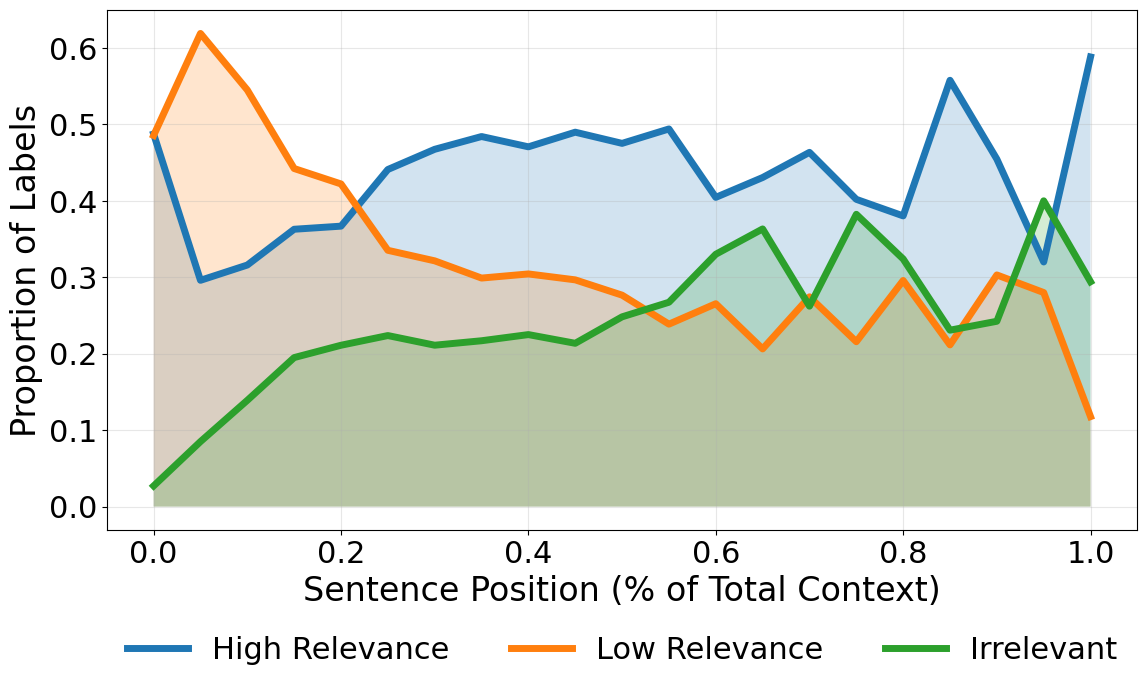

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load data
merged_df = pd.read_csv(paths.DATA / "MAJORITY_Vote_GPT4o_Self_Reported_Relevancy_Labels.csv")

# Setup
label_cols = [f"label_{i}" for i in range(1, 22)]
label_map = {"High Relevance": 0, "Low Relevance": 1, "Irrelevant": 2}
label_names = ["High Relevance", "Low Relevance", "Irrelevant"]
label_counts = np.zeros((21, 3))  # sentence position × label category

# Count labels
for i, col in enumerate(label_cols):
    counts = merged_df[col].dropna().apply(str.strip).value_counts()
    for label, count in counts.items():
        if label in label_map:
            label_counts[i, label_map[label]] += count

# Normalize
label_props = label_counts / label_counts.sum(axis=1, keepdims=True)

# Plot
x = np.linspace(0, 1, 21)
plt.figure(figsize=(12, 7))
for i in range(3):
    plt.plot(x, label_props[:, i], label=label_names[i], linewidth=5)
    plt.fill_between(x, label_props[:, i], alpha=0.2)

plt.xlabel("Sentence Position (% of Total Context)", fontsize=24)
plt.ylabel("Proportion of Labels", fontsize=24)
# plt.title("Sentence-Level Relevance Distribution Across Context GPT4o", fontsize=26)
plt.legend(
    loc='upper center',
    bbox_to_anchor=(0.5, -0.15),
    ncol=3,
    fontsize=22,
    frameon=False
)
plt.xticks(fontsize=22)
plt.yticks(fontsize=22)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(paths.FIGURES / "4o_self_report_relevance_distribution.pdf", format='pdf', bbox_inches='tight')

plt.show()


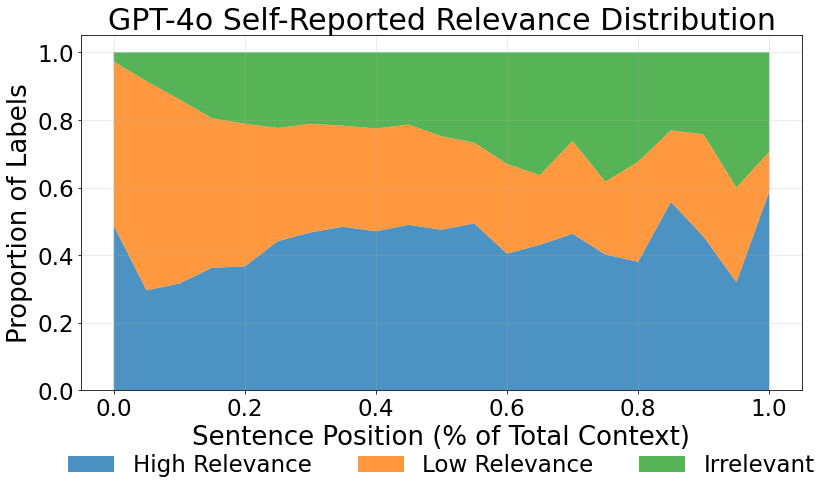

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl

# === Global Style ===
mpl.rcParams['font.size']             = 52
mpl.rcParams['axes.titlesize']        = 38
mpl.rcParams['axes.labelsize']        = 26
mpl.rcParams['xtick.labelsize']       = 23
mpl.rcParams['ytick.labelsize']       = 23
mpl.rcParams['legend.fontsize']       = 23
mpl.rcParams['legend.title_fontsize'] = 25
mpl.rcParams['figure.titlesize']      = 30

# === Load Data ===
maj_df = pd.read_csv(paths.DATA / "MAJORITY_Vote_GPT4o_Self_Reported_Relevancy_Labels.csv")

# === Compute proportions ===
label_cols = [f"label_{i}" for i in range(1, 22)]
labels     = ["High Relevance", "Low Relevance", "Irrelevant"]
label_map  = {lab: idx for idx, lab in enumerate(labels)}

counts = np.zeros((len(label_cols), len(labels)))
for idx, col in enumerate(label_cols):
    vc = maj_df[col].dropna().str.strip().value_counts()
    for lab, cnt in vc.items():
        if lab in label_map:
            counts[idx, label_map[lab]] = cnt

# Avoid division by zero
sums  = counts.sum(axis=1, keepdims=True)
props = np.divide(counts, sums, out=np.zeros_like(counts), where=sums!=0)

# === Prepare for plotting ===
x      = np.linspace(0, 1, len(label_cols))
colors = ['#1f77b4', '#ff7f0e', '#2ca02c']

# === Create Stackplot ===
plt.figure(figsize=(12, 7))
plt.stackplot(x, props.T, labels=labels, colors=colors, alpha=0.8)

plt.title("GPT-4o Self-Reported Relevance Distribution", fontsize=30)
plt.xlabel("Sentence Position (% of Total Context)", fontsize=26)
plt.ylabel("Proportion of Labels", fontsize=26)
plt.grid(alpha=0.3)

# Place legend beneath the plot
plt.legend(
    loc='upper center',
    bbox_to_anchor=(0.5, -0.12),
    ncol=3,
    frameon=False
)

plt.tight_layout()
plt.savefig(paths.FIGURES / "4o_self_report_relevance_stackplot.pdf", format='pdf', bbox_inches='tight')
plt.show()
